# Mediterranean SST — Monthly Time Series at Two Pixels (1987–2025)

This notebook follows the same data loading and anomaly approach as
`copernicus_sst_anomaly_mediterranean.ipynb` and then extracts pixel-level
time series at two representative locations:

| Label | Location | Approx. coordinates |
|---|---|---|
| North Adriatic (Venice) | Northern Adriatic Sea, offshore Venice | 45.3 °N, 12.5 °E |
| Gulf of Lion (near Italy) | Eastern Gulf of Lion, near French-Italian Riviera | 43.3 °N, 7.5 °E |

**Plots produced**
1. Map showing the actual model grid-points selected.
2. Raw SST monthly time series (1987–2025) for both pixels.
3. SST anomaly monthly time series for both pixels (with ±1 σ envelope).
4. Monthly climatology (mean seasonal cycle) for both pixels.

> **Credentials**: requires a `~/.netrc` entry for `auth.marine.copernicus.eu`.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import xarray as xr
import copernicusmarine
import hvplot.xarray
import hvplot.pandas
import holoviews as hv
import panel as pn
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

pn.extension()

In [2]:
# Mediterranean bounding box and time range — identical to the SST anomaly notebook
MED_BBOX = dict(
    minimum_longitude=-6,
    maximum_longitude=42,
    minimum_latitude=30,
    maximum_latitude=47,
)
TIME_START = "1987-01-01"
TIME_END   = "2025-12-31"

# Pixel definitions — (lat, lon) chosen to lie in open-water model cells
PIXELS = {
    "North Adriatic (Venice)": {"lat": 45.3, "lon": 12.5},
    "Gulf of Lion (near Italy)": {"lat": 43.3, "lon": 7.5},
}
COLORS = {
    "North Adriatic (Venice)": "#1f77b4",   # blue
    "Gulf of Lion (near Italy)": "#d62728",  # red
}

## 1 — Open the SST dataset (lazy)

Same dataset and subsetting as `copernicus_sst_anomaly_mediterranean.ipynb`.

In [3]:
%%time
ds = copernicusmarine.open_dataset(
    dataset_id="cmems_mod_med_phy-temp_my_4.2km_P1M-m",
    start_datetime=TIME_START,
    end_datetime=TIME_END,
    **MED_BBOX,
)

# Surface SST only (depth nearest 0 m)
sst = ds["thetao"].sel(depth=0, method="nearest")
sst.attrs["long_name"] = "Sea Surface Temperature"
sst.attrs["units"]     = "°C"
print(f"SST shape: {dict(zip(sst.dims, sst.shape))}")
sst

INFO - 2026-04-23T16:59:17Z - Selected dataset version: "202511"
INFO - 2026-04-23T16:59:17Z - Selected dataset part: "default"
WARNING - 2026-04-23T16:59:17Z - Some of your subset selection [30.0, 47.0] for the latitude dimension exceed the dataset coordinates [30.1875, 45.97916793823242]
WARNING - 2026-04-23T16:59:17Z - Some of your subset selection [-6.0, 42.0] for the longitude dimension exceed the dataset coordinates [-6.0, 36.29166793823242]


SST shape: {'time': 468, 'latitude': 380, 'longitude': 1016}
CPU times: user 3.07 s, sys: 924 ms, total: 4 s
Wall time: 7.04 s


<xarray.DataArray 'thetao' (time: 468, latitude: 380, longitude: 1016)> Size: 723MB
dask.array<getitem, shape=(468, 380, 1016), dtype=float32, chunksize=(100, 380, 1016), chunktype=numpy.ndarray>
Coordinates:
    depth      float32 4B 1.018
  * latitude   (latitude) float32 2kB 30.19 30.23 30.27 ... 45.9 45.94 45.98
  * longitude  (longitude) float32 4kB -6.0 -5.958 -5.917 ... 36.21 36.25 36.29
  * time       (time) datetime64[ns] 4kB 1987-01-01 1987-02-01 ... 2025-12-01
Attributes:
    long_name:      Sea Surface Temperature
    standard_name:  sea_water_potential_temperature
    units:          °C
    valid_max:      40.0
    valid_min:      1.0

## 2 — Long-term climatological mean

In [4]:
%%time
sst_clim = sst.mean(dim="time").compute()
sst_clim.attrs["long_name"] = f"Climatological Mean SST ({TIME_START[:4]}\u2013{TIME_END[:4]})"
sst_clim.attrs["units"]     = "\u00b0C"
print(f"Clim SST range: {float(sst_clim.min()):.1f} \u2013 {float(sst_clim.max()):.1f} \u00b0C")

Clim SST range: 15.7 – 23.5 °C
CPU times: user 11.6 s, sys: 7.79 s, total: 19.4 s
Wall time: 7.52 s


## 3 — Monthly SST anomaly

In [5]:
sst_anom = sst - sst_clim
sst_anom.attrs["long_name"] = "SST Anomaly"
sst_anom.attrs["units"]     = "\u00b0C"
print(f"Anomaly shape: {dict(zip(sst_anom.dims, sst_anom.shape))}")

Anomaly shape: {'time': 468, 'latitude': 380, 'longitude': 1016}


## 4 — Extract pixel time series

Select the nearest model grid-point to each target location, then load both
SST and SST anomaly into memory (each pixel time series is tiny: 468 floats).

In [6]:
pixel_info = {}   # stores actual snapped coordinates
pixel_sst  = {}   # raw SST  time series
pixel_anom = {}   # anomaly  time series

for name, coords in PIXELS.items():
    ts_sst  = sst.sel(latitude=coords["lat"],  longitude=coords["lon"],  method="nearest").compute()
    ts_anom = sst_anom.sel(latitude=coords["lat"], longitude=coords["lon"], method="nearest").compute()

    snapped_lat = float(ts_sst.latitude)
    snapped_lon = float(ts_sst.longitude)
    pixel_info[name] = {"lat": snapped_lat, "lon": snapped_lon}
    pixel_sst[name]  = ts_sst
    pixel_anom[name] = ts_anom

    print(f"{name:35s}  requested ({coords['lat']:.1f}°N, {coords['lon']:.1f}°E)  "
          f"→  snapped ({snapped_lat:.3f}°N, {snapped_lon:.3f}°E)")

North Adriatic (Venice)              requested (45.3°N, 12.5°E)  →  snapped (45.312°N, 12.500°E)
Gulf of Lion (near Italy)            requested (43.3°N, 7.5°E)  →  snapped (43.312°N, 7.500°E)


## 5 — Location map

Quick sanity check: plot the two selected grid-points on a Mediterranean map.

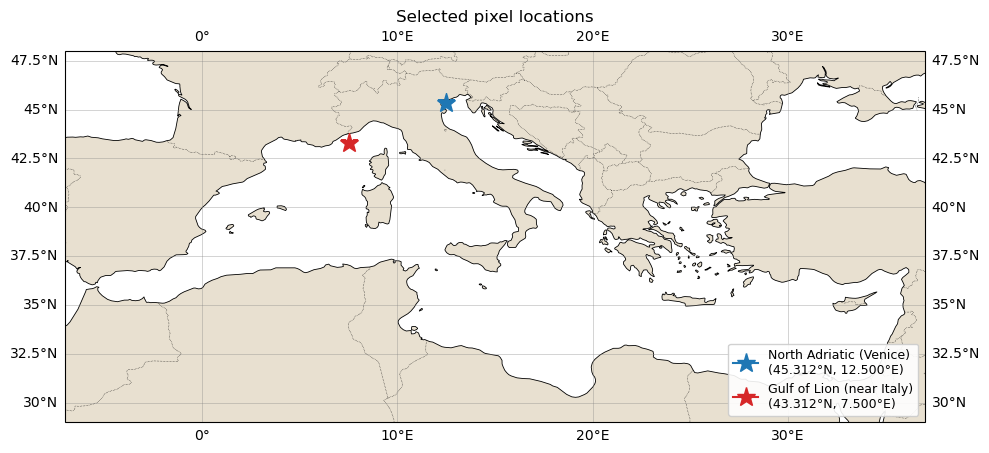

In [7]:
fig, ax = plt.subplots(
    figsize=(10, 5),
    subplot_kw={"projection": ccrs.PlateCarree()},
)
ax.set_extent([-7, 37, 29, 48], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor="#e8e0d0", zorder=1)
ax.add_feature(cfeature.COASTLINE, linewidth=0.6, zorder=2)
ax.add_feature(cfeature.BORDERS, linewidth=0.4, linestyle=":", zorder=2)
ax.gridlines(draw_labels=True, linewidth=0.4, color="gray", alpha=0.6)

for name, info in pixel_info.items():
    ax.plot(
        info["lon"], info["lat"],
        marker="*", markersize=14,
        color=COLORS[name],
        transform=ccrs.PlateCarree(),
        zorder=3,
        label=f"{name}\n({info['lat']:.3f}°N, {info['lon']:.3f}°E)",
    )

ax.legend(loc="lower right", fontsize=9, framealpha=0.9)
ax.set_title("Selected pixel locations", fontsize=12)
plt.tight_layout()
plt.show()

## 6 — Raw SST monthly time series (1987–2025)

In [8]:
# Build a tidy pandas DataFrame: one column per pixel
time_index = pd.to_datetime(pixel_sst[list(PIXELS)[0]].time.values)

df_sst = pd.DataFrame(
    {name: ts.values for name, ts in pixel_sst.items()},
    index=time_index,
)
df_sst.index.name = "time"
df_sst.head(3)

,North Adriatic (Venice),Gulf of Lion (near Italy)
time,,
1987-01-01,7.230145,12.970451
1987-02-01,6.744386,12.829978
1987-03-01,6.681080,12.820544


In [9]:
sst_curves = df_sst.hvplot.line(
    x="time",
    y=list(PIXELS.keys()),
    color=list(COLORS.values()),
    line_width=1.2,
    alpha=0.85,
    ylabel="SST (\u00b0C)",
    xlabel="",
    title=f"Monthly Sea Surface Temperature — {TIME_START[:4]}\u2013{TIME_END[:4]}",
    frame_width=900,
    frame_height=350,
    fontscale=1.2,
    legend="top_left",
)
sst_curves

:NdOverlay   [Variable]
   :Curve   [time]   (value)

## 7 — SST anomaly monthly time series (1987–2025)

In [10]:
df_anom = pd.DataFrame(
    {name: ts.values for name, ts in pixel_anom.items()},
    index=time_index,
)
df_anom.index.name = "time"
df_anom.head(3)

,North Adriatic (Venice),Gulf of Lion (near Italy)
time,,
1987-01-01,-9.534903,-4.837885
1987-02-01,-10.020660,-4.978358
1987-03-01,-10.083967,-4.987792


In [11]:
anom_curves = df_anom.hvplot.line(
    x="time",
    y=list(PIXELS.keys()),
    color=list(COLORS.values()),
    line_width=1.2,
    alpha=0.85,
    ylabel="SST Anomaly (\u00b0C)",
    xlabel="",
    title=f"Monthly SST Anomaly (w.r.t. {TIME_START[:4]}\u2013{TIME_END[:4]} mean)",
    frame_width=900,
    frame_height=350,
    fontscale=1.2,
    legend="top_left",
)

# Add a horizontal zero reference line
zero_line = hv.HLine(0).opts(color="black", line_dash="dashed", line_width=0.8, alpha=0.6)

anom_curves * zero_line

:Overlay
   .NdOverlay.I :NdOverlay   [Variable]
      :Curve   [time]   (value)
   .HLine.I     :HLine   [x,y]

## 8 — Monthly climatology (mean seasonal cycle)

Average SST by calendar month (1–12) to reveal the seasonal signal at each location.

In [12]:
MONTH_NAMES = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

df_cycle_mean = df_sst.groupby(df_sst.index.month).mean()
df_cycle_std  = df_sst.groupby(df_sst.index.month).std()
df_cycle_mean.index = MONTH_NAMES
df_cycle_std.index  = MONTH_NAMES

df_cycle_mean

,North Adriatic (Venice),Gulf of Lion (near Italy)
Jan,8.803581,13.534663
Feb,7.924433,13.148187
Mar,9.457342,13.323277
Apr,12.938555,14.279295
May,17.964046,17.172665
Jun,22.724224,20.980108
Jul,25.576921,23.919987
Aug,26.149055,24.727226
Sep,23.541698,21.918488
Oct,19.498152,19.276289


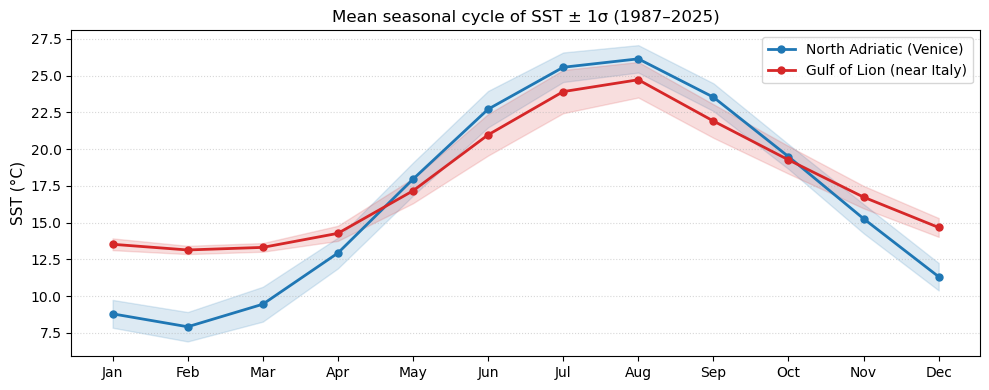

In [13]:
fig, ax = plt.subplots(figsize=(10, 4))

for name, color in COLORS.items():
    mean = df_cycle_mean[name]
    std  = df_cycle_std[name]
    ax.plot(MONTH_NAMES, mean, color=color, lw=2, marker="o", ms=5, label=name)
    ax.fill_between(
        MONTH_NAMES,
        mean - std, mean + std,
        color=color, alpha=0.15,
    )

ax.set_ylabel("SST (\u00b0C)", fontsize=11)
ax.set_title(
    f"Mean seasonal cycle of SST \u00b1 1\u03c3 ({TIME_START[:4]}\u2013{TIME_END[:4]})",
    fontsize=12,
)
ax.legend(fontsize=10)
ax.grid(axis="y", linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

## 9 — Combined view: SST and anomaly stacked

In [14]:
(sst_curves + (anom_curves * zero_line)).cols(1)

:Layout
   .NdOverlay.I :NdOverlay   [Variable]
      :Curve   [time]   (value)
   .Overlay.I   :Overlay
      .NdOverlay.I :NdOverlay   [Variable]
         :Curve   [time]   (value)
      .HLine.I     :HLine   [x,y]

## 10 — Per-pixel detailed view (matplotlib)

Two-panel figure for each pixel: raw SST on top, anomaly (bar-coloured by sign) on the bottom.

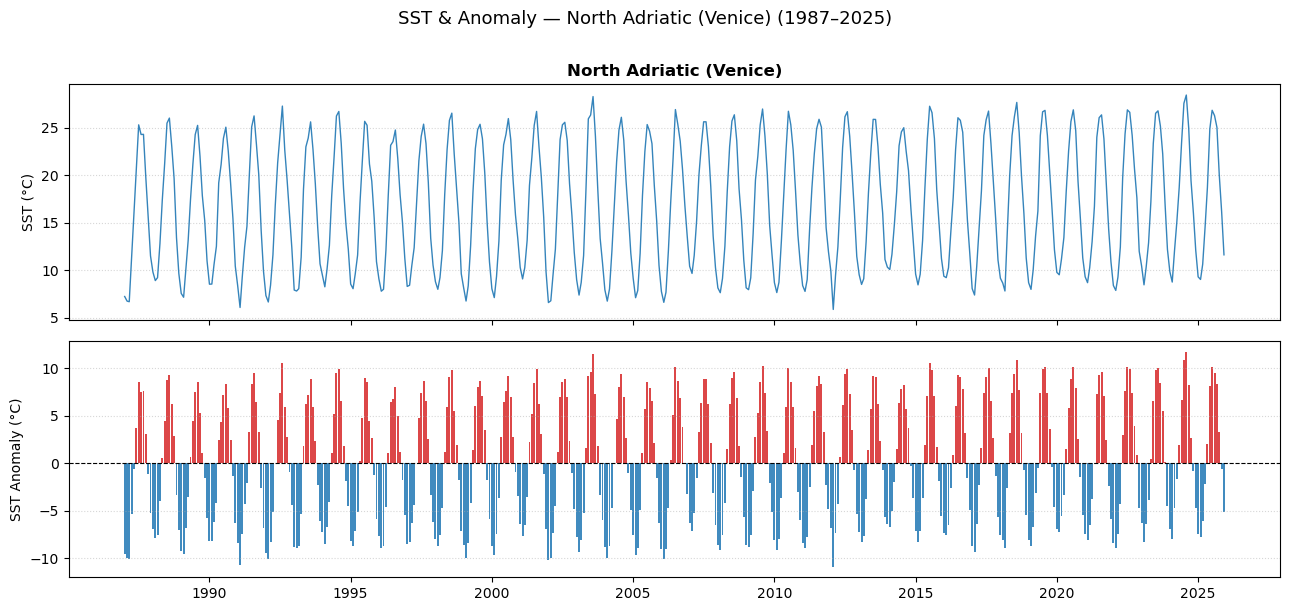

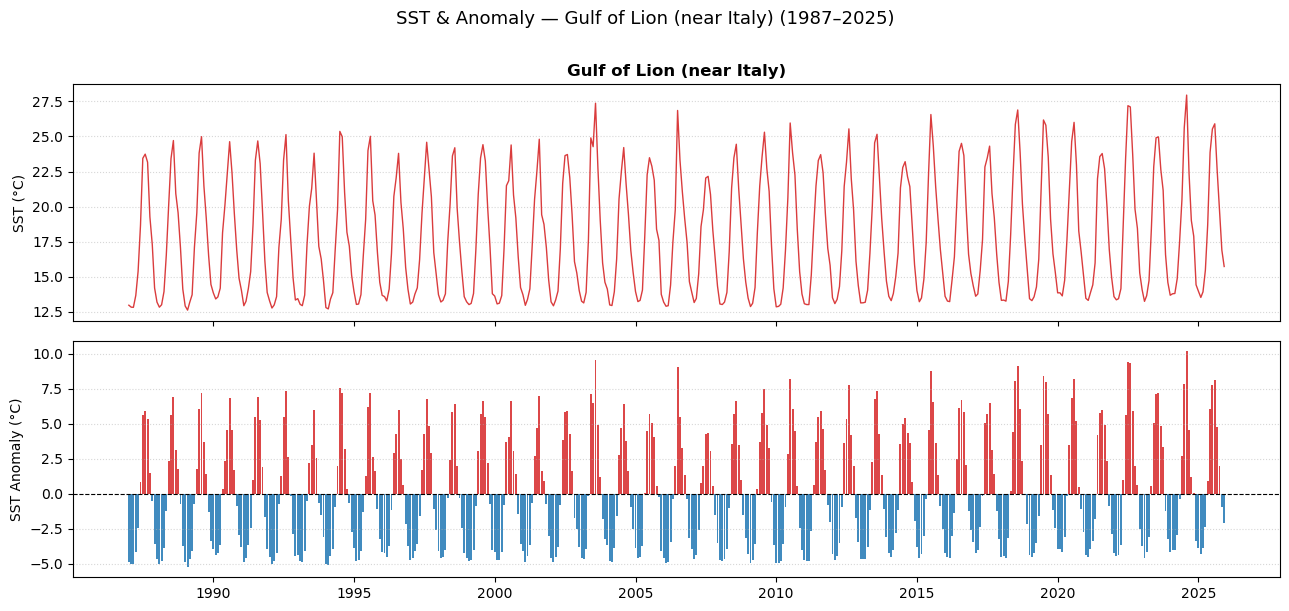

In [15]:
def plot_pixel(name, color):
    ts_sst  = df_sst[name]
    ts_anom = df_anom[name]
    bar_colors = ["#d62728" if v >= 0 else "#1f77b4" for v in ts_anom]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

    # --- top: raw SST ---
    ax1.plot(ts_sst.index, ts_sst.values, color=color, lw=1.0, alpha=0.9)
    ax1.set_ylabel("SST (\u00b0C)", fontsize=10)
    ax1.set_title(name, fontsize=12, fontweight="bold")
    ax1.grid(axis="y", linestyle=":", alpha=0.5)

    # --- bottom: anomaly bars ---
    ax2.bar(ts_anom.index, ts_anom.values, width=25, color=bar_colors, alpha=0.85)
    ax2.axhline(0, color="black", lw=0.8, linestyle="--")
    ax2.set_ylabel("SST Anomaly (\u00b0C)", fontsize=10)
    ax2.xaxis.set_major_locator(mdates.YearLocator(5))
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax2.grid(axis="y", linestyle=":", alpha=0.5)

    fig.suptitle(
        f"SST & Anomaly — {name} ({TIME_START[:4]}\u2013{TIME_END[:4]})",
        fontsize=13, y=1.01,
    )
    plt.tight_layout()
    plt.show()

for name, color in COLORS.items():
    plot_pixel(name, color)

## 11 — Annual SST and anomaly time series

Resample the monthly pixel time series to yearly means, then plot both raw SST
and anomaly at annual resolution.

In [16]:
# Resample monthly DataFrames to annual means
df_sst_annual  = df_sst.resample("YE").mean()
df_anom_annual = df_anom.resample("YE").mean()

# Use integer years as the index for cleaner x-axis labels
df_sst_annual.index  = df_sst_annual.index.year
df_anom_annual.index = df_anom_annual.index.year
df_sst_annual.index.name  = "year"
df_anom_annual.index.name = "year"

df_anom_annual

,North Adriatic (Venice),Gulf of Lion (near Italy)
year,,
1987,-0.969718,-0.520842
1988,-0.375249,-0.354988
1989,-0.758206,-0.344928
1990,-0.333076,0.015721
1991,-0.973217,-0.365180
1992,-0.590137,-0.843487
1993,-0.661083,-0.803915
1994,0.093401,-0.209126
1995,-0.571369,-0.353618


In [17]:
# Annual SST — interactive hvplot
sst_annual_curves = df_sst_annual.hvplot.line(
    x="year",
    y=list(PIXELS.keys()),
    color=list(COLORS.values()),
    line_width=2,
    marker="o",
    ms=6,
    ylabel="SST (°C)",
    xlabel="Year",
    title=f"Annual Mean SST — {TIME_START[:4]}–{TIME_END[:4]}",
    frame_width=900,
    frame_height=350,
    fontscale=1.2,
    legend="top_left",
)
sst_annual_curves

:NdOverlay   [Variable]
   :Curve   [year]   (value)

In [18]:
# Annual SST anomaly — bar chart coloured by sign, both pixels side by side
plots = []
for name, color in COLORS.items():
    vals = df_anom_annual[name]
    bar_colors = ["#d62728" if v >= 0 else "#1f77b4" for v in vals]
    p = vals.hvplot.bar(
        color=bar_colors,
        ylabel="SST Anomaly (°C)",
        xlabel="Year",
        title=name,
        frame_width=500,
        frame_height=300,
        fontscale=1.1,
        rot=45,
    ) * hv.HLine(0).opts(color="black", line_dash="dashed", line_width=0.8)
    plots.append(p)

hv.Layout(plots).cols(2)

:Layout
   .Overlay.North_Adriatic_left_parenthesis_Venice_right_parenthesis   :Overlay
      .Bars.North_Adriatic_left_parenthesis_Venice_right_parenthesis :Bars   [year]   (North Adriatic (Venice))
      .HLine.I                                                       :HLine   [x,y]
   .Overlay.Gulf_of_Lion_left_parenthesis_near_Italy_right_parenthesis :Overlay
      .Bars.Gulf_of_Lion_left_parenthesis_near_Italy_right_parenthesis :Bars   [year]   (Gulf of Lion (near Italy))
      .HLine.I                                                         :HLine   [x,y]